# Results: gene expression prediction

Explores a `predict_gene_expression.py` run: training curves, which target genes are easiest/hardest to predict, and which input features (mutation status vs. subtype flags) matter most to the model.

In [10]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import fastcluster
from scipy.cluster.hierarchy import leaves_list
from sklearn.model_selection import train_test_split

from model import MLP, TwoHeadMLP
from predict_gene_expression import load_dataset, r2_per_gene

In [11]:
runs_dir = Path("more_targets")
RUN = None  # set to a specific "predict_gene_expression_..." run dir name, or None to auto-pick the latest


def find_latest_run(prefix="predict_gene_expression_", runs_dir=runs_dir):
    candidates = [p for p in runs_dir.iterdir() if p.is_dir() and p.name.startswith(prefix)]
    if not candidates:
        raise FileNotFoundError(f"No runs found in {runs_dir} matching prefix={prefix!r}")
    return max(candidates, key=lambda p: p.stat().st_mtime)


RUN_DIR = runs_dir / RUN if RUN else find_latest_run()

config = json.loads((RUN_DIR / "config.json").read_text())
history_df = pd.read_csv(RUN_DIR / "history.csv")
target_genes = json.loads((RUN_DIR / "target_genes.json").read_text())
per_gene_df = pd.read_csv(RUN_DIR / "val_per_gene_metrics.csv")

print(f"Run: {RUN_DIR.name}")
print(json.dumps(config, indent=2))

Run: predict_gene_expression_20260908_162119
{
  "n_mutation_genes": 10000,
  "n_target_genes": 10000,
  "input_source": "both",
  "mutation_selection": "univariate",
  "min_mutation_count": 6,
  "mutation_score_agg": "mean",
  "architecture": "two_head",
  "hidden_dims": [
    512,
    256,
    128
  ],
  "hidden_dims_mutation": [
    1024,
    512,
    256
  ],
  "hidden_dims_subtype": [
    128
  ],
  "dropout": 0.1,
  "weight_decay": 0.0001,
  "patience": 20,
  "pretrain_subtype": true,
  "pretrain_epochs": 200,
  "pretrain_patience": 20,
  "l1_mutation": 0.0001,
  "val_split": 0.2,
  "batch_size": 128,
  "lr": 0.001,
  "epochs": 200,
  "seed": 0,
  "n_samples": 1643,
  "n_input_features": 5109,
  "n_target_genes_actual": 10000,
  "n_mutation_input_features": 4779,
  "n_subtype_input_features": 330,
  "pretrain_best_epoch": 51,
  "pretrain_val_r2": 0.2813671827316284,
  "best_epoch": 27,
  "stopped_early": true
}


## Training curves

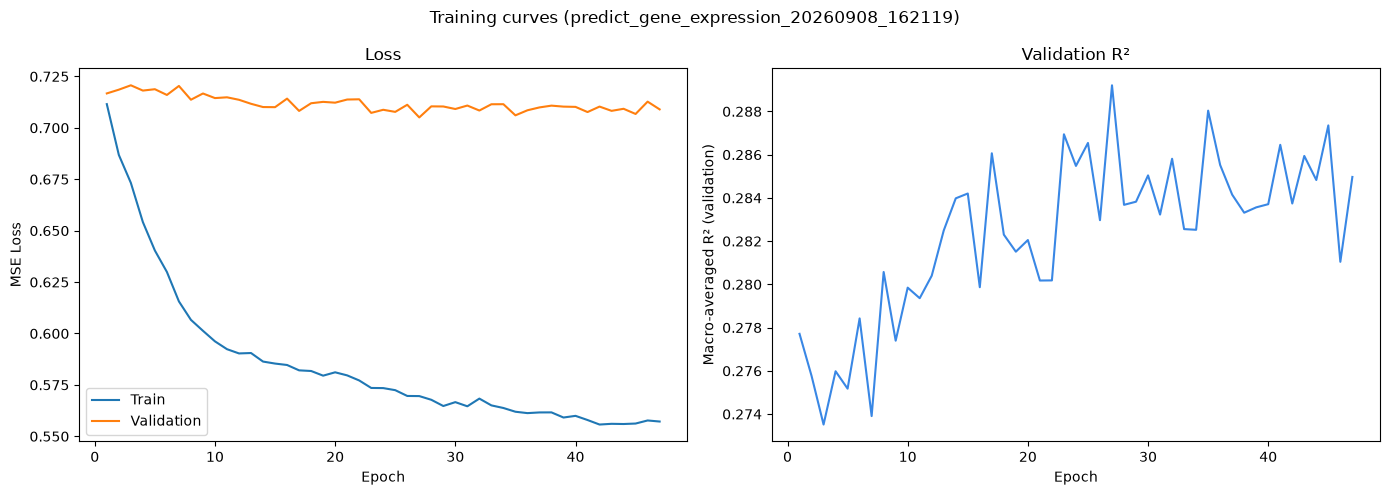

Best epoch by val_loss: 27/47 (val_loss=0.705, val_r2=0.289) vs. final epoch val_r2=0.285


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Train')
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['val_r2'], color='#3987e5')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro-averaged R² (validation)')
axes[1].set_title('Validation R²')

fig.suptitle(f"Training curves ({RUN_DIR.name})")
plt.tight_layout()
plt.show()

best_epoch = history_df.loc[history_df['val_loss'].idxmin()]
print(
    f"Best epoch by val_loss: {int(best_epoch['epoch'])}/{len(history_df)} "
    f"(val_loss={best_epoch['val_loss']:.3f}, val_r2={best_epoch['val_r2']:.3f}) "
    f"vs. final epoch val_r2={history_df['val_r2'].iloc[-1]:.3f}"
)

## Which genes are easiest / hardest to predict?

`val_per_gene_metrics.csv` already has per-gene R² and Pearson correlation. With potentially thousands of target genes, a distribution plot is more informative than eyeballing a full table, alongside the clearest examples at each end.

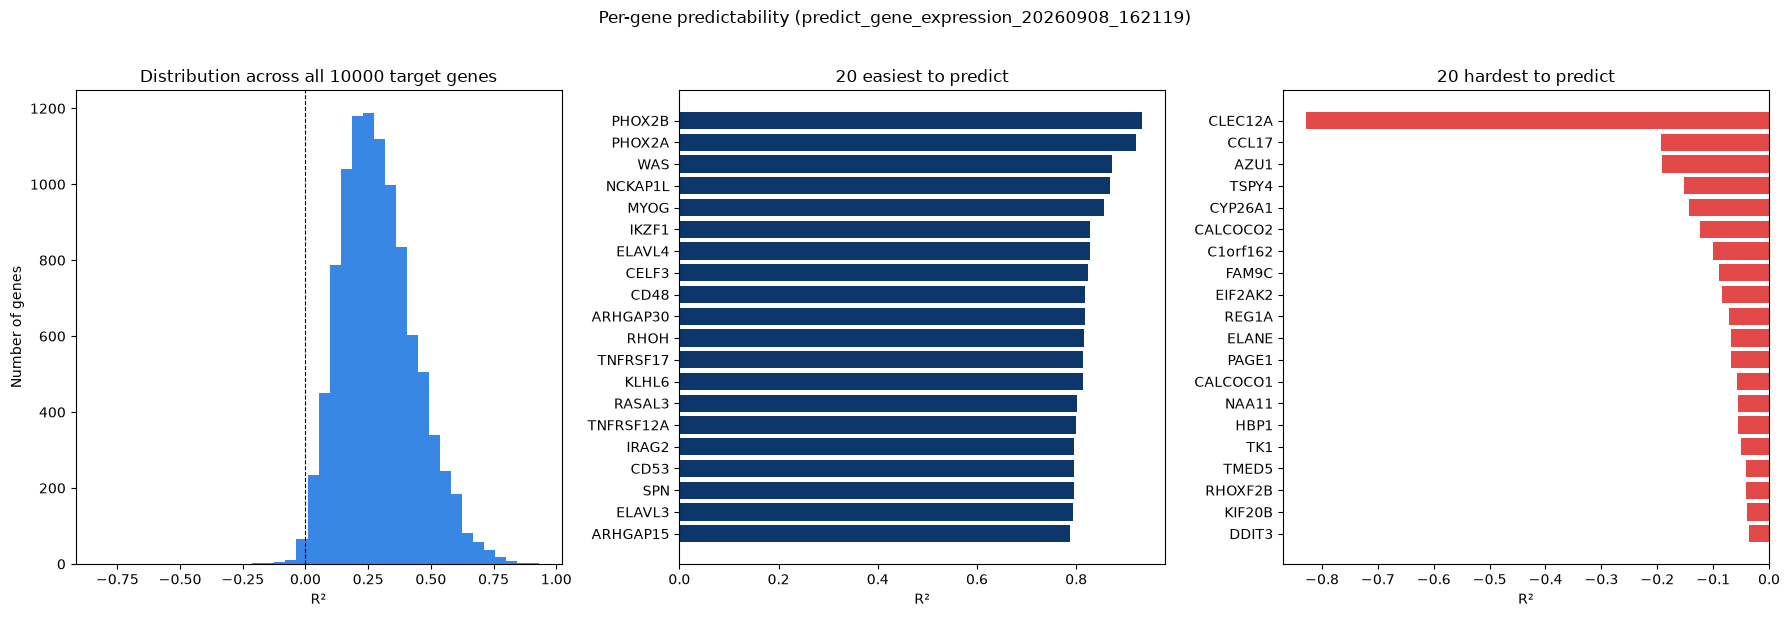

64/10000 genes have negative R² (worse than predicting the training mean)


In [13]:
TOP_N_GENES = 20

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].hist(per_gene_df['r2'], bins=40, color='#3987e5')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('R²')
axes[0].set_ylabel('Number of genes')
axes[0].set_title(f'Distribution across all {len(per_gene_df)} target genes')

easiest = per_gene_df.nlargest(TOP_N_GENES, 'r2').sort_values('r2')
axes[1].barh(easiest['gene'], easiest['r2'], color='#0d366b')
axes[1].set_xlabel('R²')
axes[1].set_title(f'{TOP_N_GENES} easiest to predict')

hardest = per_gene_df.nsmallest(TOP_N_GENES, 'r2').sort_values('r2', ascending=False)
axes[2].barh(hardest['gene'], hardest['r2'], color='#e34948')
axes[2].set_xlabel('R²')
axes[2].set_title(f'{TOP_N_GENES} hardest to predict')

fig.suptitle(f"Per-gene predictability ({RUN_DIR.name})", y=1.02)
plt.tight_layout()
plt.show()

n_negative = (per_gene_df['r2'] < 0).sum()
print(f"{n_negative}/{len(per_gene_df)} genes have negative R² (worse than predicting the training mean)")

## Which input features matter most?

Reconstructs the exact model and validation split from the saved run (same seed, same `load_dataset(...)` call, same scalers) so the analysis below runs against the actual trained weights rather than a fresh model. `input_features.json` (mutation gene / subtype flag names, in the same column order as the model's input) is saved by newer runs of `predict_gene_expression.py`; older runs fall back to recomputing it via `load_dataset`, which is deterministic given the same config and underlying CSVs.

With potentially tens of thousands of input features, per-feature permutation importance (shuffle one column, measure the drop in performance) doesn't scale — it would mean one full forward pass per feature. Instead:
1. **First-layer connection weights** give an importance score for *every* feature in O(1) — since inputs are standardized (mean 0, std 1) before training, the L2 norm of each feature's outgoing weights in the first layer is a fair, instant proxy for how much the model relies on it.
2. **Permutation importance** (the more rigorous, model-agnostic method) is then run only on the weight-based shortlist, to sanity-check that ranking against actual validation performance drop.

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Reload the data exactly as the training run did. .get(...) fallbacks keep this
# working for older runs saved before input_source/mutation_selection existed.
X, Y, input_features_reloaded, _ = load_dataset(
    config["n_mutation_genes"], config["n_target_genes"],
    input_source=config.get("input_source", "both"),
    mutation_selection=config.get("mutation_selection", "frequency"),
    min_mutation_count=config.get("min_mutation_count", 10),
    mutation_score_agg=config.get("mutation_score_agg", "mean"),
    val_split=config["val_split"], seed=config["seed"],
)

input_features_path = RUN_DIR / "input_features.json"
if input_features_path.exists():
    input_features = json.loads(input_features_path.read_text())
else:
    input_features = input_features_reloaded
    print("input_features.json not found (older run) - recomputed from load_dataset() instead.")
input_features = np.array(input_features)

# Same split as training (same seed + val_split), so this is the real held-out set.
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=config["val_split"], random_state=config["seed"]
)

input_scaler = np.load(RUN_DIR / "input_scaler.npz")
target_scaler = np.load(RUN_DIR / "target_scaler.npz")
X_val_scaled = (X_val - input_scaler["mean"]) / input_scaler["scale"]
Y_val_scaled = (Y_val - target_scaler["mean"]) / target_scaler["scale"]

architecture = config.get("architecture", "single")
if architecture == "two_head":
    # TwoHeadMLP.forward() still takes one concatenated tensor (same calling
    # convention as MLP) and splits it internally at input_dim_a - the model
    # itself just needs the mutation/subtype feature counts saved in config.
    model = TwoHeadMLP(
        input_dim_a=config["n_mutation_input_features"],
        input_dim_b=config["n_subtype_input_features"],
        hidden_dims_a=config["hidden_dims_mutation"],
        hidden_dims_b=config["hidden_dims_subtype"],
        hidden_dims_shared=config["hidden_dims"],
        num_classes=Y.shape[1],
        dropout=config["dropout"],
    ).to(device)
else:
    model = MLP(
        input_dim=X.shape[1], hidden_dims=config["hidden_dims"], num_classes=Y.shape[1], dropout=config["dropout"]
    ).to(device)
model.load_state_dict(torch.load(RUN_DIR / "model.pt", map_location=device))
model.eval()

X_val_t = torch.from_numpy(X_val_scaled).float().to(device)


def macro_r2(y_true, y_pred):
    """Macro-averaged R² across target genes, using predict_gene_expression's
    own variance-guarded per-gene R² (avoids blow-up on near-constant genes)."""
    per_gene = r2_per_gene(y_true, y_pred)
    return float(np.nanmean(per_gene)), per_gene


with torch.no_grad():
    baseline_preds = model(X_val_t).cpu().numpy()
baseline_r2, _ = macro_r2(Y_val_scaled, baseline_preds)

# model.pt is the best-epoch checkpoint (early stopping restores it), not
# necessarily history.csv's last row - compare against that epoch specifically.
if "best_epoch" in config:
    reference_row = history_df.loc[history_df["epoch"] == config["best_epoch"]].iloc[0]
    reference_label = f"best epoch {config['best_epoch']}"
else:
    reference_row = history_df.iloc[-1]  # older runs saved the final epoch, not the best
    reference_label = "final epoch (older run, saved before early stopping was added)"
print(f"Reconstructed validation R²: {baseline_r2:.4f} (should match the run's {reference_label} val_r2 of {reference_row['val_r2']:.4f})")

Only 4779 mutation genes pass min_mutation_count=6 (requested 10000); using all of them.
Reconstructed validation R²: 0.2892 (should match the run's best epoch 27 val_r2 of 0.2892)


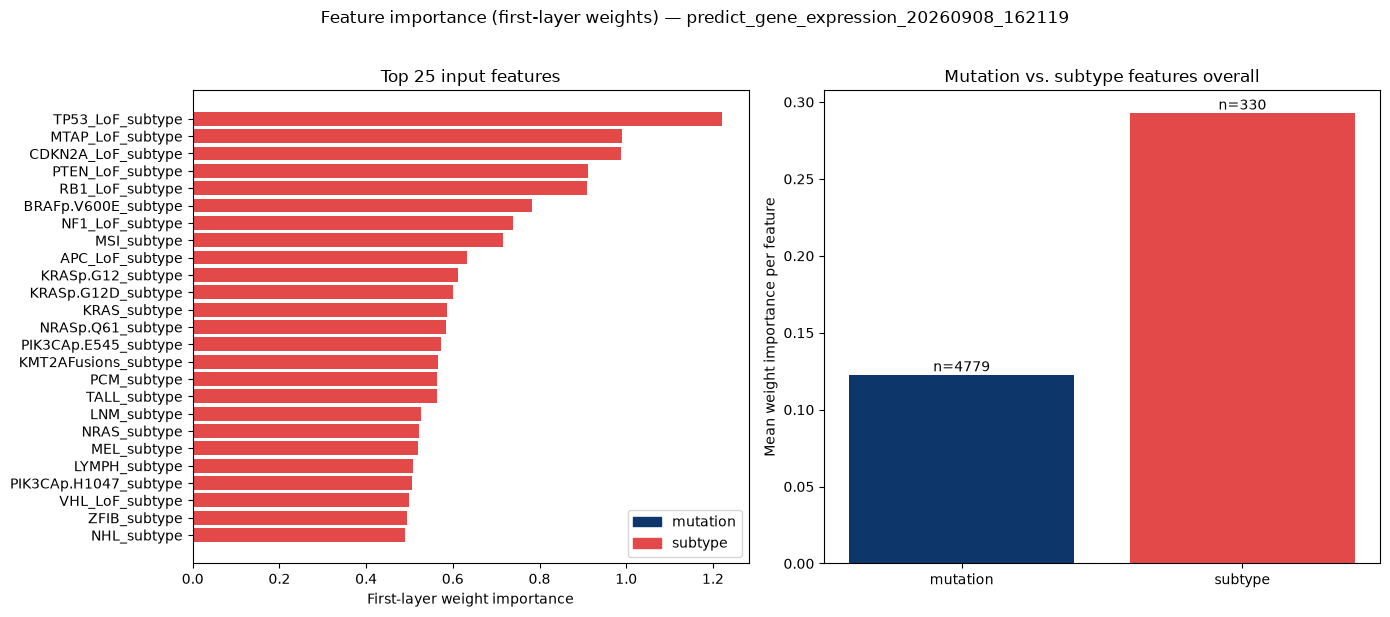

,sum,mean,count
source,,,
mutation,586.687683,0.122764,4779
subtype,96.670441,0.292941,330


In [15]:
TOP_N_FEATURES = 25


def first_layer_norms(branch):
    """L2 norm of each input's outgoing weights in a branch's first Linear
    layer - None if the branch has no hidden layers (nn.Identity)."""
    for m in branch.modules():
        if isinstance(m, nn.Linear):
            return np.linalg.norm(m.weight.detach().cpu().numpy(), axis=0)
    return None


if architecture == "two_head":
    # Each block has its own first layer - concatenate in the same mutation-
    # then-subtype order load_dataset() and TwoHeadMLP both use.
    norms_a, norms_b = first_layer_norms(model.branch_a), first_layer_norms(model.branch_b)
    if norms_a is None or norms_b is None:
        raise ValueError("A two_head branch has no hidden layers - can't compute first-layer importance for it.")
    weight_importance = np.concatenate([norms_a, norms_b])
else:
    weight_importance = np.linalg.norm(model.network[0].weight.detach().cpu().numpy(), axis=0)

importance_df = pd.DataFrame({
    "feature": input_features,
    "source": np.where(np.char.endswith(input_features.astype(str), "_mut"), "mutation", "subtype"),
    "weight_importance": weight_importance,
}).sort_values("weight_importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_features = importance_df.head(TOP_N_FEATURES).sort_values("weight_importance")
colors = top_features["source"].map({"mutation": "#0d366b", "subtype": "#e34948"})
axes[0].barh(top_features["feature"], top_features["weight_importance"], color=colors)
axes[0].set_xlabel("First-layer weight importance")
axes[0].set_title(f"Top {TOP_N_FEATURES} input features")
axes[0].legend(handles=[
    plt.Rectangle((0, 0), 1, 1, color="#0d366b", label="mutation"),
    plt.Rectangle((0, 0), 1, 1, color="#e34948", label="subtype"),
])

by_source = importance_df.groupby("source")["weight_importance"].agg(["sum", "mean", "count"])
axes[1].bar(by_source.index, by_source["mean"], color=["#0d366b", "#e34948"])
axes[1].set_ylabel("Mean weight importance per feature")
axes[1].set_title("Mutation vs. subtype features overall")
for i, (source, row) in enumerate(by_source.iterrows()):
    axes[1].text(i, row["mean"], f"n={int(row['count'])}", ha="center", va="bottom")

fig.suptitle(f"Feature importance (first-layer weights) — {RUN_DIR.name}", y=1.02)
plt.tight_layout()
plt.show()

by_source

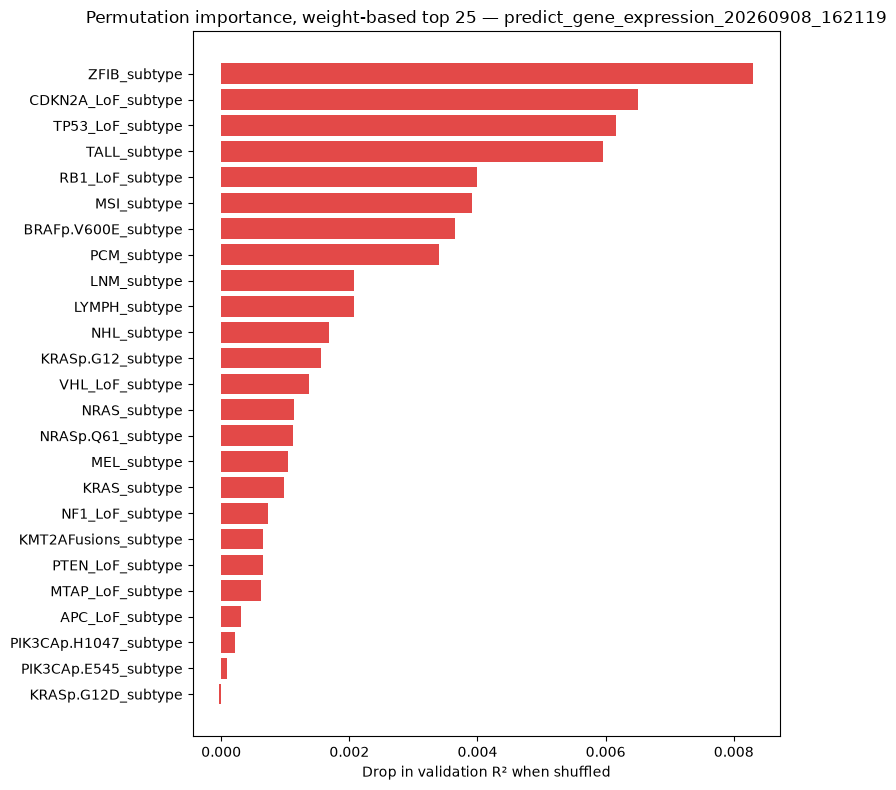

In [16]:
# Cross-check the weight-based ranking with actual permutation importance
# (shuffle the feature in the validation set, measure the drop in R²) -
# only feasible to run on a shortlist, so use the top candidates above.
PERMUTATION_CANDIDATES = 25
N_REPEATS = 3

candidate_idx = np.argsort(-weight_importance)[:PERMUTATION_CANDIDATES]
rng = np.random.default_rng(0)

perm_importance = []
for j in candidate_idx:
    drops = []
    for _ in range(N_REPEATS):
        X_permuted = X_val_scaled.copy()
        rng.shuffle(X_permuted[:, j])
        with torch.no_grad():
            preds = model(torch.from_numpy(X_permuted).float().to(device)).cpu().numpy()
        permuted_r2, _ = macro_r2(Y_val_scaled, preds)
        drops.append(baseline_r2 - permuted_r2)
    perm_importance.append(np.mean(drops))

perm_df = pd.DataFrame({
    "feature": input_features[candidate_idx],
    "source": importance_df.set_index("feature").loc[input_features[candidate_idx], "source"].values,
    "r2_drop": perm_importance,
}).sort_values("r2_drop")

fig, ax = plt.subplots(figsize=(8, 8))
colors = perm_df["source"].map({"mutation": "#0d366b", "subtype": "#e34948"})
ax.barh(perm_df["feature"], perm_df["r2_drop"], color=colors)
ax.set_xlabel("Drop in validation R² when shuffled")
ax.set_title(f"Permutation importance, weight-based top {PERMUTATION_CANDIDATES} — {RUN_DIR.name}")
plt.tight_layout()
plt.show()

## Predicted vs. actual expression

Reuses `Y_val_scaled` (actual) and `baseline_preds` (predicted) from the reconstruction above — both already in the same z-scored, gene-standardized units the model was trained on, so they're directly comparable on the same color scale used throughout `explore.ipynb` (`RdBu_r`, white = at the mean, blue = under-expressed, red = over-expressed, clipped to ±3).

Genes (columns) are ordered by validation R² — best-predicted on the left, worst on the right — so the comparison doubles as a visual version of the R² histogram above: a good model should show matching red/blue patterns between the Actual and Predicted panels on the left, fading to visually uncorrelated noise on the right. Samples (rows) are ordered by hierarchical clustering of the *actual* data, so any within-sample structure (e.g. subtype-driven blocks) is visible in both panels using the same layout. A third panel shows the residual (Actual − Predicted) directly.

In [17]:
# Order genes by predictability (best -> worst), samples by clustering the actual data.
val_r2 = r2_per_gene(Y_val_scaled, baseline_preds)
gene_order = np.argsort(-np.nan_to_num(val_r2, nan=-np.inf))

row_linkage = fastcluster.linkage_vector(Y_val_scaled, method='ward', metric='euclidean')
row_order = leaves_list(row_linkage)

actual_ordered = Y_val_scaled[row_order][:, gene_order]
predicted_ordered = baseline_preds[row_order][:, gene_order]
residual_ordered = actual_ordered - predicted_ordered

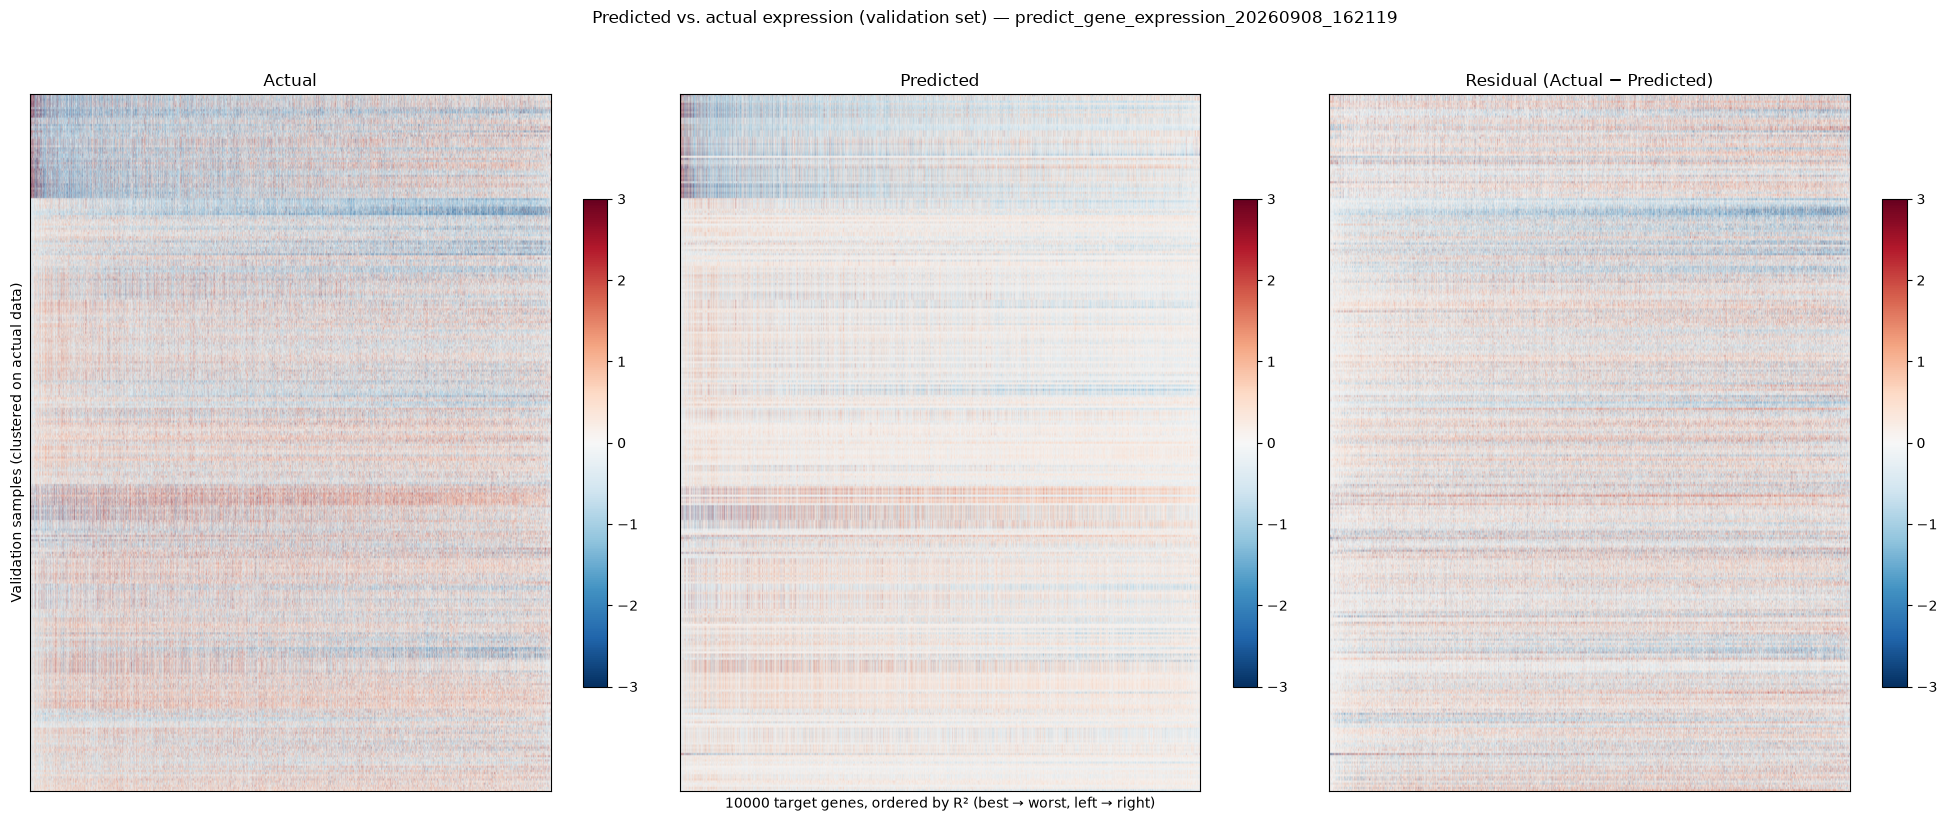

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, data, title in zip(
    axes,
    [actual_ordered, predicted_ordered, residual_ordered],
    ['Actual', 'Predicted', 'Residual (Actual − Predicted)'],
):
    im = ax.imshow(data, aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, shrink=0.7)

axes[0].set_ylabel('Validation samples (clustered on actual data)')
axes[1].set_xlabel(f'{actual_ordered.shape[1]} target genes, ordered by R² (best → worst, left → right)')

fig.suptitle(f"Predicted vs. actual expression (validation set) — {RUN_DIR.name}", y=1.02)
plt.tight_layout()
plt.show()